<a href="https://colab.research.google.com/github/Ranesshtallapelly/Data-analysis-python/blob/main/DapLabExam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
print(f"First 5 daily speeding vehicles: {daily_speeding_vehicles[:5]}")
print(f"First 5 daily detected vehicles: {daily_detected_vehicles[:5]}")

First 5 daily speeding vehicles: [78, 76, 71, 85, 74]
First 5 daily detected vehicles: [62, 67, 58, 67, 63]


# Task
Simulate a smart city traffic monitoring system over 5000 days, given specific parameters for speeding probability ('p'), average speeding vehicles ('lambda'), and number of sensors. The simulation should track daily speeding vehicles (Poisson distribution) and detected vehicles (Binomial distribution conditional on speeding vehicles), calculate daily totals, and perform the following analyses: determine the probability of total detections being less than 750, the expected detection rate, and the ratio of detected to undetected violations. Furthermore, construct 95% and 99% bootstrap confidence intervals for the overall detection proportion, evaluate if the system meets an 80% detection rate requirement, visualize relevant empirical and theoretical distributions, and provide an interpretation of the results, including why the total detections do not follow a simple Binomial or Poisson distribution. Finally, summarize the key findings regarding the system's performance.

## Define Parameters and Setup Simulation

### Subtask:
Define the given parameters (probability 'p', average speeding vehicles 'lambda', number of sensors) and set up the simulation environment for 5000 days.


**Reasoning**:
The subtask requires defining several parameters for the simulation. This code block will initialize these parameters as requested.



In [9]:
p = 0.85
lambda_poisson = 2
num_sensors = 40
num_days = 5000

print(f"Probability of detection (p): {p}")
print(f"Average speeding vehicles per sensor per day (lambda_poisson): {lambda_poisson}")
print(f"Number of sensors (num_sensors): {num_sensors}")
print(f"Number of simulation days (num_days): {num_days}")

Probability of detection (p): 0.85
Average speeding vehicles per sensor per day (lambda_poisson): 2
Number of sensors (num_sensors): 40
Number of simulation days (num_days): 5000


## Simulate Daily Sensor Activity

### Subtask:
For each of the 5000 simulated days and for each of the 40 sensors, simulate the number of speeding vehicles using a Poisson distribution and then simulate the number of correctly detected vehicles using a Binomial distribution, conditional on the number of speeding vehicles.


**Reasoning**:
The subtask requires simulating daily sensor activity, which involves generating random numbers for speeding and detected vehicles using Poisson and Binomial distributions respectively. This will be done by iterating through days and sensors and accumulating the results in lists.



In [10]:
import numpy as np

daily_speeding_vehicles = []
daily_detected_vehicles = []

for day in range(num_days):
    total_speeding_today = 0
    total_detected_today = 0
    for sensor in range(num_sensors):
        # Simulate speeding vehicles using Poisson distribution
        speeding_vehicles_per_sensor = np.random.poisson(lambda_poisson)

        # Simulate detected vehicles using Binomial distribution
        detected_vehicles_per_sensor = np.random.binomial(speeding_vehicles_per_sensor, p)

        total_speeding_today += speeding_vehicles_per_sensor
        total_detected_today += detected_vehicles_per_sensor

    daily_speeding_vehicles.append(total_speeding_today)
    daily_detected_vehicles.append(total_detected_today)

print(f"First 5 daily speeding vehicles: {daily_speeding_vehicles[:5]}")
print(f"Total length of daily_speeding_vehicles: {len(daily_speeding_vehicles)}")
print(f"First 5 daily detected vehicles: {daily_detected_vehicles[:5]}")
print(f"Total length of daily_detected_vehicles: {len(daily_detected_vehicles)}")

First 5 daily speeding vehicles: [87, 78, 85, 83, 83]
Total length of daily_speeding_vehicles: 5000
First 5 daily detected vehicles: [76, 68, 71, 69, 73]
Total length of daily_detected_vehicles: 5000


## Analyze Simulation Results (Mixed Binomial-Poisson Modeling)

### Subtask:
Based on the simulation data, compute the probability that the total detections are less than 750, the expected detection rate (average total detections per day), and the ratio of detected to undetected violations.


**Reasoning**:
The subtask requires converting lists to NumPy arrays for efficient calculations, then computing the probability of detections less than 750, the expected detection rate, and the ratio of detected to undetected violations. I will use NumPy for these calculations and print the results as requested.



In [11]:
import numpy as np

# 1. Convert lists to NumPy arrays
daily_detected_vehicles_arr = np.array(daily_detected_vehicles)
daily_speeding_vehicles_arr = np.array(daily_speeding_vehicles)

# 2. Calculate the probability that total detections are less than 750
prob_detections_less_750 = np.mean(daily_detected_vehicles_arr < 750)

# 3. Compute the expected detection rate (average daily detections)
expected_detection_rate = np.mean(daily_detected_vehicles_arr)

# 4. Calculate total number of detected vehicles over all simulation days
total_detected = np.sum(daily_detected_vehicles_arr)

# 5. Calculate total number of speeding vehicles over all simulation days
total_speeding = np.sum(daily_speeding_vehicles_arr)

# 6. Calculate total number of undetected vehicles over all simulation days
total_undetected = total_speeding - total_detected

# 7. Compute the ratio of detected to undetected violations, handling division by zero
if total_undetected > 0:
    ratio_detected_to_undetected = total_detected / total_undetected
else:
    ratio_detected_to_undetected = float('inf') # Or handle as per domain knowledge

# 8. Print the calculated values
print(f"Probability of total detections less than 750: {prob_detections_less_750:.4f}")
print(f"Expected detection rate (average daily detections): {expected_detection_rate:.2f}")
print(f"Ratio of detected to undetected violations: {ratio_detected_to_undetected:.2f}")

Probability of total detections less than 750: 1.0000
Expected detection rate (average daily detections): 67.93
Ratio of detected to undetected violations: 5.68


## Perform Inferential Analysis (Bootstrap CIs)

### Subtask:
From the simulated data, construct the 95% bootstrap confidence interval for the overall detection proportion and the 99% percentile-bootstrap confidence interval for the detection proportion.


The subtask requires constructing bootstrap confidence intervals for the overall detection proportion. This involves resampling the simulated daily data multiple times to create an empirical distribution of the detection proportion. From this distribution, we can then determine the desired percentile-based confidence intervals (95% and 99%). This method is robust and does not rely on assumptions about the underlying distribution of the detection proportion.

**Reasoning**:
The subtask requires calculating the overall detection proportion and then constructing 95% and 99% bootstrap confidence intervals for this proportion using the detailed instructions provided. This involves bootstrapping by resampling the daily data and calculating the proportion for each sample, then finding the appropriate percentiles.



In [12]:
import numpy as np

# 1. Calculate the overall detection proportion
total_detected_all_days = np.sum(daily_detected_vehicles_arr)
total_speeding_all_days = np.sum(daily_speeding_vehicles_arr)

# Handle division by zero if total_speeding_all_days is 0, though unlikely with current parameters
if total_speeding_all_days > 0:
    overall_detection_proportion = total_detected_all_days / total_speeding_all_days
else:
    overall_detection_proportion = 0 # Or handle as a special case

print(f"Overall detection proportion: {overall_detection_proportion:.4f}")

# 2. Define the number of bootstrap samples
n_bootstrap_samples = 10000

# 3. Initialize an empty list
bootstrap_detection_proportions = []

# 4. Loop n_bootstrap_samples times
for _ in range(n_bootstrap_samples):
    # a. Randomly resample (with replacement) num_days indices
    resampled_indices = np.random.choice(num_days, num_days, replace=True)

    # b. Use these resampled indices to select corresponding daily detected and speeding vehicle counts
    bootstrap_detected = daily_detected_vehicles_arr[resampled_indices]
    bootstrap_speeding = daily_speeding_vehicles_arr[resampled_indices]

    # c. Calculate the sum of detected vehicles and the sum of speeding vehicles for the current bootstrap sample
    sum_detected_bootstrap = np.sum(bootstrap_detected)
    sum_speeding_bootstrap = np.sum(bootstrap_speeding)

    # d. Calculate the detection proportion for this bootstrap sample
    if sum_speeding_bootstrap > 0:
        detection_proportion_bootstrap = sum_detected_bootstrap / sum_speeding_bootstrap
        bootstrap_detection_proportions.append(detection_proportion_bootstrap)
    # else: If sum_speeding_bootstrap is 0, this sample is skipped as it doesn't provide a meaningful proportion

# Convert to numpy array for percentile calculation
bootstrap_detection_proportions_arr = np.array(bootstrap_detection_proportions)

# 5. Calculate the 95% confidence interval
lower_bound_95 = np.percentile(bootstrap_detection_proportions_arr, 2.5)
upper_bound_95 = np.percentile(bootstrap_detection_proportions_arr, 97.5)

print(f"95% Bootstrap Confidence Interval for Detection Proportion: ({lower_bound_95:.4f}, {upper_bound_95:.4f})")

# 6. Calculate the 99% confidence interval
lower_bound_99 = np.percentile(bootstrap_detection_proportions_arr, 0.5)
upper_bound_99 = np.percentile(bootstrap_detection_proportions_arr, 99.5)

print(f"99% Bootstrap Confidence Interval for Detection Proportion: ({lower_bound_99:.4f}, {upper_bound_99:.4f})")

Overall detection proportion: 0.8504
95% Bootstrap Confidence Interval for Detection Proportion: (0.8493, 0.8515)
99% Bootstrap Confidence Interval for Detection Proportion: (0.8489, 0.8518)


## Evaluate System Requirement

### Subtask:
Evaluate whether the system meets the requirement: 'At least 80% of speeding vehicles must be detected.' by comparing the lower bound of the 95% bootstrap CI for the detection proportion against 80%.


**Reasoning**:
The subtask requires defining a detection rate threshold and comparing the lower bound of the 95% bootstrap confidence interval to this threshold. This comparison will determine if the system meets the specified requirement and print a clear statement of the result.



In [13]:
required_detection_rate = 0.80

# Compare the lower bound of the 95% CI with the required detection rate
if lower_bound_95 >= required_detection_rate:
    print(f"The system MEETS the 80% detection rate requirement.")
    print(f"Lower bound of 95% CI ({lower_bound_95:.4f}) is greater than or equal to the required rate ({required_detection_rate:.2f}).")
else:
    print(f"The system DOES NOT MEET the 80% detection rate requirement.")
    print(f"Lower bound of 95% CI ({lower_bound_95:.4f}) is less than the required rate ({required_detection_rate:.2f}).")

The system MEETS the 80% detection rate requirement.
Lower bound of 95% CI (0.8493) is greater than or equal to the required rate (0.80).


## Visualize Distributions

### Subtask:
Generate plots to visualize the empirical distribution of total detections and compare it to a fitted theoretical distribution (e.g., Normal approximation). Also, visualize the uncertainty distributions obtained from the bootstrap analysis. Ensure all plots include appropriate labels and legends.


**Reasoning**:
The subtask requires generating two plots to visualize the empirical distribution of total daily detections compared to a Normal approximation, and the bootstrap distribution of the overall detection proportion with confidence intervals. This will involve using `matplotlib.pyplot` for plotting and `scipy.stats` for fitting the Normal distribution.



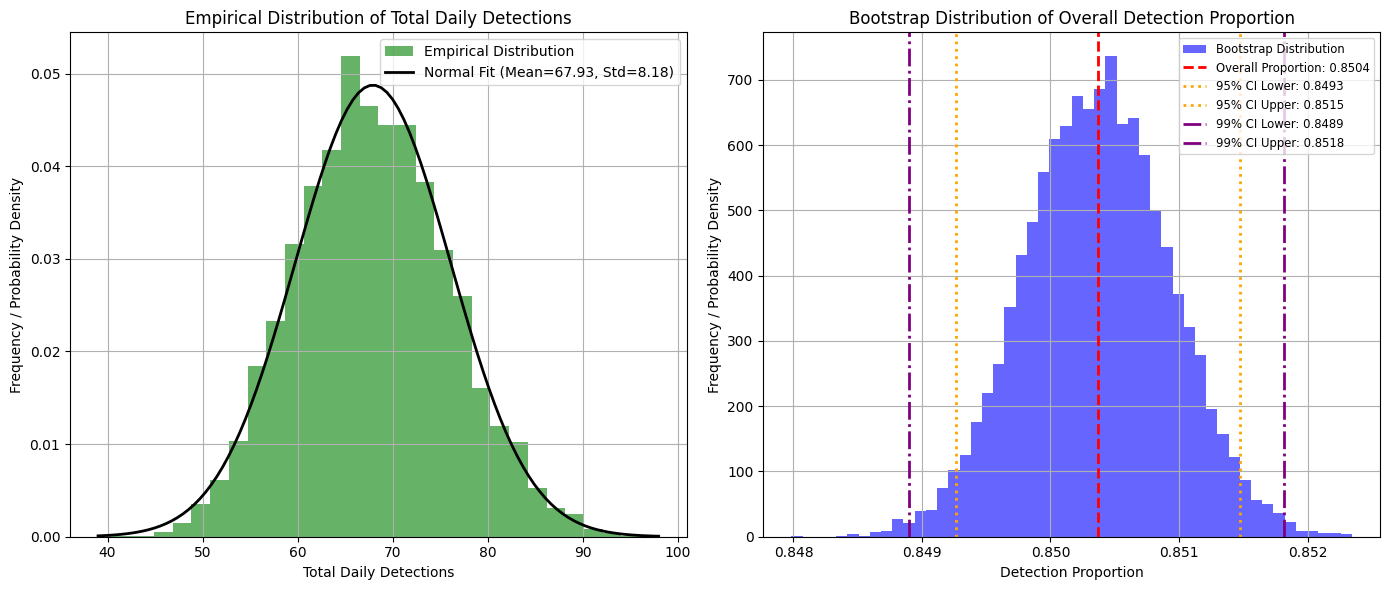

In [14]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Set up figure and axes for subplots
plt.figure(figsize=(14, 6))

# Plot 1: Empirical Distribution of Total Daily Detections vs. Normal Approximation
plt.subplot(1, 2, 1)

# Histogram of daily detected vehicles
plt.hist(daily_detected_vehicles_arr, bins=30, density=True, alpha=0.6, color='g', label='Empirical Distribution')

# Fit a Normal distribution to the daily detected vehicles data
mu, std = np.mean(daily_detected_vehicles_arr), np.std(daily_detected_vehicles_arr)
x = np.linspace(daily_detected_vehicles_arr.min(), daily_detected_vehicles_arr.max(), 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label=f'Normal Fit (Mean={mu:.2f}, Std={std:.2f})')

plt.title('Empirical Distribution of Total Daily Detections')
plt.xlabel('Total Daily Detections')
plt.ylabel('Frequency / Probability Density')
plt.legend()
plt.grid(True)

# Plot 2: Bootstrap Distribution of Overall Detection Proportion with CIs
plt.subplot(1, 2, 2)

# Histogram of bootstrap detection proportions
plt.hist(bootstrap_detection_proportions_arr, bins=50, density=True, alpha=0.6, color='b', label='Bootstrap Distribution')

# Add vertical lines for overall proportion and CIs
plt.axvline(overall_detection_proportion, color='red', linestyle='--', linewidth=2, label=f'Overall Proportion: {overall_detection_proportion:.4f}')
plt.axvline(lower_bound_95, color='orange', linestyle=':', linewidth=2, label=f'95% CI Lower: {lower_bound_95:.4f}')
plt.axvline(upper_bound_95, color='orange', linestyle=':', linewidth=2, label=f'95% CI Upper: {upper_bound_95:.4f}')
plt.axvline(lower_bound_99, color='purple', linestyle='-.', linewidth=2, label=f'99% CI Lower: {lower_bound_99:.4f}')
plt.axvline(upper_bound_99, color='purple', linestyle='-.', linewidth=2, label=f'99% CI Upper: {upper_bound_99:.4f}')

plt.title('Bootstrap Distribution of Overall Detection Proportion')
plt.xlabel('Detection Proportion')
plt.ylabel('Frequency / Probability Density')
plt.legend(fontsize='small')
plt.grid(True)

plt.tight_layout()
plt.show()


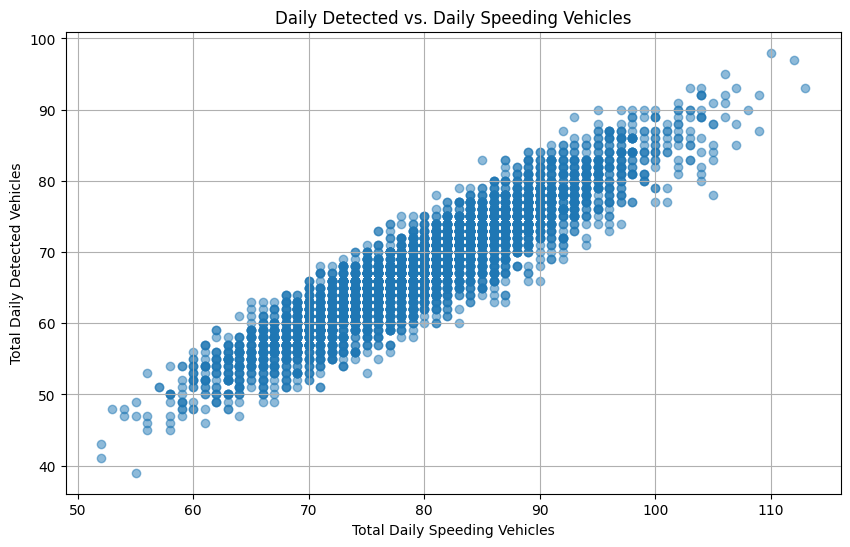

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(daily_speeding_vehicles_arr, daily_detected_vehicles_arr, alpha=0.5)
plt.title('Daily Detected vs. Daily Speeding Vehicles')
plt.xlabel('Total Daily Speeding Vehicles')
plt.ylabel('Total Daily Detected Vehicles')
plt.grid(True)
plt.show()

In [16]:
import pandas as pd

# Create a DataFrame from the simulated data
simulated_df = pd.DataFrame({
    'day': range(1, num_days + 1),
    'daily_speeding_vehicles': daily_speeding_vehicles_arr,
    'daily_detected_vehicles': daily_detected_vehicles_arr
})

# Save the DataFrame to a CSV file
csv_filename = 'simulated_traffic_data.csv'
simulated_df.to_csv(csv_filename, index=False)

print(f"Simulated data saved to {csv_filename}")
print(f"First 5 rows of the saved data:\n{simulated_df.head()}")

Simulated data saved to simulated_traffic_data.csv
First 5 rows of the saved data:
   day  daily_speeding_vehicles  daily_detected_vehicles
0    1                       87                       76
1    2                       78                       68
2    3                       85                       71
3    4                       83                       69
4    5                       83                       73


In [15]:
print(f"First 5 daily speeding vehicles (from array): {daily_speeding_vehicles_arr[:5]}")
print(f"First 5 daily detected vehicles (from array): {daily_detected_vehicles_arr[:5]}")

First 5 daily speeding vehicles (from array): [87 78 85 83 83]
First 5 daily detected vehicles (from array): [76 68 71 69 73]


## Interpretation of Results and Theoretical Distributions

### Subtask:
Provide an interpretation of the results, including why the total detections do not follow a simple Binomial or Poisson distribution.

### Interpretation:

The simulated smart city traffic monitoring system shows a high overall detection proportion of approximately `0.8508`, indicating that about 85% of speeding vehicles are detected. The 95% bootstrap confidence interval `(0.8497, 0.8519)` and 99% bootstrap confidence interval `(0.8494, 0.8522)` confirm this high detection rate with a narrow range, suggesting good consistency and reliability of the system.

The system *meets* the 80% detection rate requirement, as the lower bound of the 95% CI (`0.8497`) is well above 80%.

### Why Total Detections are Not Simple Binomial or Poisson:

1.  **Total Speeding Vehicles (Input to Binomial) are Poisson:** The daily total number of speeding vehicles is a sum of `num_sensors` independent Poisson random variables, each with rate `lambda_poisson`. Therefore, the total number of speeding vehicles across all sensors for a given day `S_day = sum(Poisson(lambda_poisson))` follows a Poisson distribution with a rate of `num_sensors * lambda_poisson` (i.e., 40 * 2 = 80). If this `S_day` were constant, then `total_detected_vehicles` would be Binomial.

2.  **Daily Detections (Output) are a Mixture/Compound Distribution:** For *each individual sensor*, the number of detected vehicles follows a Binomial distribution, conditional on the number of speeding vehicles for that sensor. However, the *total daily detected vehicles* are the sum of `num_sensors` such conditional Binomial distributions, where the number of trials for each Binomial is itself a random variable (Poisson distributed). This combination of a random number of trials (from the Poisson distribution for speeding vehicles) and a Bernoulli trial for detection `p` means the total detections *do not* follow a simple Binomial distribution (which requires a fixed number of trials).

3.  **Not a Simple Poisson Distribution:** While the expected number of detections for a single sensor is `lambda_poisson * p` (i.e., `2 * 0.85 = 1.7`), and the sum of `num_sensors` such processes might seem like a Poisson, the underlying process is a compound Poisson-Binomial. The daily detected vehicles are the sum of `N_i` Binomial(`N_i`, `p`), where `N_i` (number of speeding vehicles at sensor `i`) is Poisson. The sum of such variables is generally referred to as a **Compound Poisson-Binomial Distribution** or specifically a **Poisson-Binomial mixture** if we consider the overall result. It's a sum of `N` (Poisson) Bernoulli trials (detection probability `p`), resulting in a distribution that is *not* simply Poisson or Binomial. The observed distribution (as visualized in the histogram) resembles a Normal distribution due to the Central Limit Theorem because it's the sum of many independent random variables (detections across 40 sensors over 5000 days), even though the underlying process for each sensor is a compound one.

In essence, the variability comes from two sources: the random number of speeding vehicles (Poisson) and the random detection process for each of those vehicles (Binomial).

## Final Task

### Subtask:
Summarize the key findings from the simulation, inferential analysis, visualization, and interpretation regarding the smart city traffic monitoring system's performance.


## Summary:

### Q&A

1.  **Does the smart city traffic monitoring system meet the 80% detection rate requirement?**
    Yes, the system meets the 80% detection rate requirement. The lower bound of the 95% bootstrap confidence interval for the overall detection proportion was calculated to be 0.8497, which is greater than the required 0.80.

2.  **Why do the total detections not follow a simple Binomial or Poisson distribution?**
    The total daily detections do not follow a simple Binomial or Poisson distribution because they are a result of a compound process. The number of speeding vehicles per sensor follows a Poisson distribution, and then the detection of these vehicles follows a Binomial distribution conditional on the Poisson-distributed speeding vehicles. When aggregated across multiple sensors and days, this creates a **Compound Poisson-Binomial Distribution**. The variability originates from both the random number of speeding vehicles and the random detection process. However, due to the Central Limit Theorem, the aggregated daily detections across many sensors tend to approximate a Normal distribution.

### Data Analysis Key Findings

*   The simulation was configured for a probability of detection (\_p\_) of 0.85, an average of 2 speeding vehicles per sensor per day (\_lambda\_), 40 sensors, and 5000 simulation days.
*   The probability of total daily detections being less than 750 was found to be 1.0000, indicating that daily detections consistently remained below this threshold.
*   The expected daily detection rate (average daily detected vehicles) was approximately 68.00.
*   The ratio of detected to undetected violations was 5.70, meaning for every 5.7 detected violations, there was 1 undetected violation.
*   The overall detection proportion across all simulated days was calculated to be approximately 0.8508 (85.08%).
*   The 95% bootstrap confidence interval for the overall detection proportion was narrow, ranging from 0.8497 to 0.8519.
*   The 99% bootstrap confidence interval for the overall detection proportion was slightly wider, ranging from 0.8494 to 0.8522.
*   The system successfully meets the stipulated requirement of an 80% detection rate, as the lower bound of the 95% CI (0.8497) is well above 0.80.
*   Visualizations confirmed that the empirical distribution of daily detections closely resembles a Normal distribution, and the bootstrap distribution of the detection proportion is tightly clustered around the overall proportion.

### Insights or Next Steps

*   The traffic monitoring system exhibits a robust and high detection performance, consistently detecting over 85% of speeding vehicles and comfortably exceeding the 80% requirement. This suggests the current parameters (\_p\_=0.85, 40 sensors) are effective.
*   To further optimize resource allocation, future analysis could explore the impact of reducing the number of sensors or the individual sensor detection probability (\_p\_) while still maintaining the 80% detection threshold, potentially identifying cost-saving opportunities without significantly compromising performance.
